<a href="https://colab.research.google.com/github/gleis7/my-app/blob/main/kronos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import nbformat
import sys
import os

def clean_notebook_metadata(filepath):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            nb = nbformat.read(f, as_version=4)

        # Remove the problematic widgets metadata
        if 'widgets' in nb.metadata:
            del nb.metadata['widgets']
            print(f"Removed 'widgets' from metadata in {filepath}")

        with open(filepath, 'w', encoding='utf-8') as f:
            nbformat.write(nb, f)
    except Exception as e:
        print(f"Error processing {filepath}: {e}")

# Automatically clean any .ipynb files found in the current directory
for root, dirs, files in os.walk('.'):
    for file in files:
        if file.endswith('.ipynb'):
            clean_notebook_metadata(os.path.join(root, file))

# Kronos Deployment
Cloning the repository from `https://github.com/shiyu-coder/Kronos`.

In [ ]:
!git clone https://github.com/shiyu-coder/Kronos.git
%cd Kronos

Cloning into 'Kronos'...
remote: Enumerating objects: 371, done.
remote: Counting objects: 100% (149/149), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 371 (delta 103), reused 91 (delta 91), pack-reused 222 (from 1)
Receiving objects: 100% (371/371), 9.30 MiB | 24.54 MiB/s, done.
Resolving deltas: 100% (185/185), done.
/content/Kronos


Next, we should check for a `requirements.txt` or setup script to install dependencies.

In [ ]:
!ls -F

examples/  finetune/	  LICENSE  README.md	     tests/
figures/   finetune_csv/  model/   requirements.txt  webui/


## 1. Install Dependencies
Installing the required Python packages from `requirements.txt`.

In [ ]:
!pip install -r requirements.txt

### Download Pre-trained Model
Downloading the model weights and tokenizer configuration from the Hugging Face Hub.

In [12]:
from huggingface_hub import snapshot_download
import os

# Define the model repository
model_repo = "NeoQuasar/Kronos-base"
tokenizer_repo = "NeoQuasar/Kronos-Tokenizer-base"

# Download files to the local model directory
os.makedirs("model", exist_ok=True)

print(f"Downloading model from {model_repo}...")
snapshot_download(repo_id=model_repo, local_dir="model", local_dir_use_symlinks=False)

print(f"Downloading tokenizer from {tokenizer_repo}...")
snapshot_download(repo_id=tokenizer_repo, local_dir="model", local_dir_use_symlinks=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:980: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

'/content/Kronos/model'

## 2. Verify Model Assets
Checking the `model/` directory for pre-trained weights.

In [13]:
!ls -F model/

config.json  kronos.py		module.py     README.md
__init__.py  model.safetensors	__pycache__/


/content/Kronos
Loading weights from local directory
Loading weights from local directory
Generating prediction for ./finetune_csv/data/HK_ali_09988_kline_5min_all.csv...


100%|██████████| 120/120 [00:20<00:00,  5.93it/s]


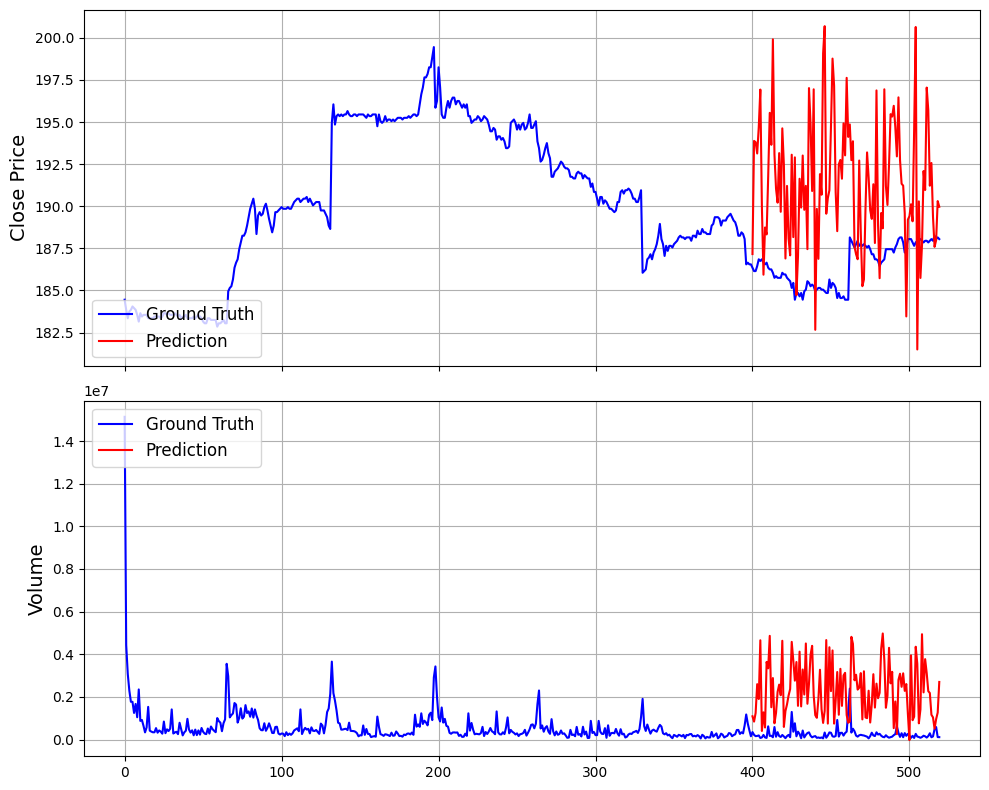

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import json

# Ensure we are in the project directory
%cd /content/Kronos
sys.path.append(os.getcwd())

from model import Kronos, KronosTokenizer, KronosPredictor

def plot_prediction(kline_df, pred_df):
    pred_df.index = kline_df.index[-pred_df.shape[0]:]
    sr_close = kline_df['close']
    sr_pred_close = pred_df['close']
    sr_close.name = 'Ground Truth'
    sr_pred_close.name = "Prediction"

    sr_volume = kline_df['volume']
    sr_pred_volume = pred_df['volume']
    sr_volume.name = 'Ground Truth'
    sr_pred_volume.name = "Prediction"

    close_df = pd.concat([sr_close, sr_pred_close], axis=1)
    volume_df = pd.concat([sr_volume, sr_pred_volume], axis=1)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    ax1.plot(close_df['Ground Truth'], label='Ground Truth', color='blue', linewidth=1.5)
    ax1.plot(close_df['Prediction'], label='Prediction', color='red', linewidth=1.5)
    ax1.set_ylabel('Close Price', fontsize=14)
    ax1.legend(loc='lower left', fontsize=12)
    ax1.grid(True)

    ax2.plot(volume_df['Ground Truth'], label='Ground Truth', color='blue', linewidth=1.5)
    ax2.plot(volume_df['Prediction'], label='Prediction', color='red', linewidth=1.5)
    ax2.set_ylabel('Volume', fontsize=14)
    ax2.legend(loc='upper left', fontsize=12)
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# 1. Load Tokenizer
tokenizer = KronosTokenizer.from_pretrained("./model")

# Manually load config to handle constructor arguments
with open("./model/config.json", "r") as f:
    config_data = json.load(f)

# 2. Load Model with explicit parameters
model = Kronos.from_pretrained(
    "./model",
    n_layers=config_data.get("n_layers", 8),
    token_dropout_p=config_data.get("token_dropout_p", 0.0),
    learn_te=config_data.get("learn_te", True)
)

# 3. Instantiate Predictor
predictor = KronosPredictor(model, tokenizer, max_context=512)

# 4. Prepare Data (Using an available file from the repo)
data_path = "./finetune_csv/data/HK_ali_09988_kline_5min_all.csv"
df = pd.read_csv(data_path)
df['timestamps'] = pd.to_datetime(df['timestamps'])

lookback = 400
pred_len = 120

x_df = df.loc[:lookback-1, ['open', 'high', 'low', 'close', 'volume', 'amount']]
x_timestamp = df.loc[:lookback-1, 'timestamps']
y_timestamp = df.loc[lookback:lookback+pred_len-1, 'timestamps']

# 5. Make Prediction
print(f"Generating prediction for {data_path}...")
pred_df = predictor.predict(
    df=x_df,
    x_timestamp=x_timestamp,
    y_timestamp=y_timestamp,
    pred_len=pred_len,
    T=1.0,
    top_p=0.9,
    sample_count=1,
    verbose=True
)

# 6. Visualize Results
kline_df = df.loc[:lookback+pred_len-1]
plot_prediction(kline_df, pred_df)